In [15]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.4 MB/s eta 0:00:00


In [16]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO is ready")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO is ready


In [17]:
import os

print(os.listdir("/content"))

['.config', 'Fall Detection.v1-raw-images.yolov11 (1).zip', 'drive', 'yolo11n.pt', 'fall_dataset', 'Fall Detection.v1-raw-images.yolov11.zip', 'sample_data']


In [59]:
import os

for f in os.listdir("/content"):
    if "Fall Detection" in f:
        print("Found:", f)

Found: Fall Detection.v1-raw-images.yolov11 (1) (1).zip


In [60]:
import os

print("Files in /content:")
for f in os.listdir("/content"):
    print(f)

Files in /content:
.config
drive
yolo11n.pt
.ipynb_checkpoints
Fall Detection.v1-raw-images.yolov11 (1) (1).zip
fall_dataset
sample_data


In [37]:
import shutil
import os

extract_path = "/content/fall_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

print("Fresh fall_dataset folder created")

Fresh fall_dataset folder created


In [39]:
import os
import shutil

extract_path = "/content/fall_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

print("Ready:", extract_path)

Ready: /content/fall_dataset


In [40]:
import zipfile
import os

zip_path = "/content/Fall Detection.v1-raw-images.yolov11.zip"
extract_path = "/content/fall_dataset"

with zipfile.ZipFile(zip_path, "r") as z:
    count = 0

    for member in z.infolist():

        # Skip folders
        if member.is_dir():
            continue

        # Get safe filename
        filename = os.path.basename(member.filename)

        # Skip unusual/invalid filenames
        if not filename:
            continue

        # Create a simple output name
        output_file = os.path.join(extract_path, filename)

        try:
            with z.open(member) as source:
                with open(output_file, "wb") as target:
                    target.write(source.read())

            count += 1

            if count % 100 == 0:
                print("Extracted:", count)

        except Exception as e:
            print("Skipped:", member.filename)
            print("Reason:", e)

print("Total extracted:", count)

Skipped: README.dataset.txt
Reason: [Errno 22] Invalid argument
Skipped: README.roboflow.txt
Reason: [Errno 22] Invalid argument
Skipped: data.yaml
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
Reason: [Errno 22] Invalid argument
Skipped: test/imag

In [42]:
import os

files = os.listdir("/content/fall_dataset")

print("Total files:", len(files))
print("\nFirst 30 files:")

for f in files[:30]:
    print(f)

Total files: 7682

First 30 files:
people-275-_jpg.rf.cc7cd75c0f30d23215e54b68c93a250e.jpg
people-1356-_jpg.rf.b3288fc5de57d6c532de14463e5661cf.txt
people-5511-_jpg.rf.71fb311359d0b2064ac7cd8e40b15581.jpg
people-8934-_jpg.rf.f60d88301b3c909852f64436a1c005a4.txt
people-7324-_jpg.rf.ff860be8f46db804c4492f2300691565.txt
people-6448-_jpg.rf.802af7f4f6dc7fde8c6f49aa6ec7191e.txt
people-1210-_jpg.rf.e74ee80508c2d3b9931e82e177659450.txt
people-7930-_jpg.rf.368d6fa2954198279e477f5e445ee421.jpg
people-1082-_jpg.rf.d6bd7d45145735af1748eba5e5bf0cbb.txt
people-6479-_jpg.rf.dca8baa81c9b0a30c0752b56a53befb6.jpg
people-4604-_jpg.rf.f6c4fe1f11e63457fcea41d18e6a245a.jpg
people-7892-_jpg.rf.78b80227d05b15a5c8d0c094e23309f0.txt
people-8023-_jpg.rf.b9cccf954802f11d1ce464a24c60f439.txt
people-3581-_jpg.rf.0c99533b4384c75fe0b8968fe7c331c4.jpg
people-374-_jpg.rf.658dc1a25d395572495c7c6aaed34e30.txt
people-7299-_jpg.rf.b3e5cbf017bc4d62920870c847a0445b.jpg
people-7917-_jpg.rf.7a901c5f848551652eac84c2ea8fbc82.jp

In [43]:
import os

for ext in [".jpg", ".jpeg", ".png", ".txt", ".yaml"]:
    count = sum(1 for f in os.listdir("/content/fall_dataset")
                if f.lower().endswith(ext))
    print(ext, ":", count)

.jpg : 3635
.jpeg : 0
.png : 0
.txt : 4047
.yaml : 0


In [44]:
import zipfile

zip_path = "/content/Fall Detection.v1-raw-images.yolov11.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Total files inside ZIP:", len(files))

for f in files[:50]:
    print(f)

Total files inside ZIP: 9006
README.dataset.txt
README.roboflow.txt
data.yaml
test/
test/images/
test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
test/images/people-1081-_jpg.rf.f47e5868af040e62d611146430b82aec.jpg
test/images/people-113-_jpg.rf.c3f7b62e874a558f99b580b290fda0f4.jpg
test/images/people-1134-_jpg.rf.ef5e5900193ef3609d9956400092364c.jpg
test/images/people-1176-_jpg.rf.ad3011872fdcf44086464e9b193685ba.jpg
test/images/people-1189-_jpg.rf.188a0a4bd2125e992614eea756a3ba11.jpg
test/images/people-1194-_jpg.rf.113d80622c93906d4f6a47f063736be1.jpg
test/im

In [45]:
with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("\nYAML files:")
for f in files:
    if f.endswith(".yaml"):
        print(f)

print("\nImage folders/files:")
for f in files:
    if "/images/" in f:
        print(f)
        if files.index(f) > 30:
            break


YAML files:
data.yaml

Image folders/files:
test/images/
test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
test/images/people-1081-_jpg.rf.f47e5868af040e62d611146430b82aec.jpg
test/images/people-113-_jpg.rf.c3f7b62e874a558f99b580b290fda0f4.jpg
test/images/people-1134-_jpg.rf.ef5e5900193ef3609d9956400092364c.jpg
test/images/people-1176-_jpg.rf.ad3011872fdcf44086464e9b193685ba.jpg
test/images/people-1189-_jpg.rf.188a0a4bd2125e992614eea756a3ba11.jpg
test/images/people-1194-_jpg.rf.113d80622c93906d4f6a47f063736be1.jpg
test/images/people-120-_jpg.rf.5d6b33474ac8245

In [46]:
import zipfile

zip_path = "/content/Fall Detection.v1-raw-images.yolov11.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Total files inside ZIP:", len(files))

for f in files[:50]:
    print(f)

Total files inside ZIP: 9006
README.dataset.txt
README.roboflow.txt
data.yaml
test/
test/images/
test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
test/images/people-1081-_jpg.rf.f47e5868af040e62d611146430b82aec.jpg
test/images/people-113-_jpg.rf.c3f7b62e874a558f99b580b290fda0f4.jpg
test/images/people-1134-_jpg.rf.ef5e5900193ef3609d9956400092364c.jpg
test/images/people-1176-_jpg.rf.ad3011872fdcf44086464e9b193685ba.jpg
test/images/people-1189-_jpg.rf.188a0a4bd2125e992614eea756a3ba11.jpg
test/images/people-1194-_jpg.rf.113d80622c93906d4f6a47f063736be1.jpg
test/im

In [ ]:
import os
import shutil

save_folder = "/content/drive/MyDrive/Elderly_Fall_Detection"
os.makedirs(save_folder, exist_ok=True)

# Save best model
shutil.copy2(
    "/content/fall_training/fall_detection/weights/best.pt",
    save_folder + "/best.pt"
)

# Save last checkpoint
shutil.copy2(
    "/content/fall_training/fall_detection/weights/last.pt",
    save_folder + "/last.pt"
)

print("Models saved successfully!")
print(os.listdir(save_folder))

Models saved successfully!
['dataset', 'models', 'results', 'best.pt', 'last.pt']


In [2]:
import os

for root, dirs, files in os.walk("/"):
    for f in files:
        if "Fall Detection" in f:
            print(os.path.join(root, f))

In [6]:
import os

print("Files in root folder:")
for item in os.listdir("/"):
    print(repr(item))

Files in root folder:
'boot'
'dev'
'proc'
'mnt'
'etc'
'bin'
'sys'
'lib64'
'opt'
'home'
'srv'
'sbin'
'usr'
'tmp'
'root'
'var'
'lib'
'media'
'run'
'kaggle'
'content'
'.dockerenv'
'tools'
'datalab'
'python-apt'
'python-apt.tar.xz'
'sbin.usr-is-merged'
'bin.usr-is-merged'
'lib.usr-is-merged'
'NGC-DL-CONTAINER-LICENSE'


In [7]:
import os

print("CONTENT:")
for item in os.listdir("/content"):
    print(repr(item))

CONTENT:
'.config'
'drive'
'Fall Detection.v1-raw-images.yolov11.zip'
'sample_data'


In [8]:
import os
import zipfile
import glob

# Find the uploaded ZIP file
zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")
for f in zip_files:
    print(f)

ZIP files found:
/content/Fall Detection.v1-raw-images.yolov11.zip


In [9]:
zip_path = zip_files[0]
extract_path = "/content/fall_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

BadZipFile: File is not a zip file

In [ ]:
import os

print("Inside fall_dataset:")

for item in os.listdir("/content/fall_dataset"):
    print(item)

In [11]:
import glob
import os

zip_files = glob.glob("/content/*.zip")

print("ZIP files found:", len(zip_files))

for i, f in enumerate(zip_files):
    print(i, repr(f))

ZIP files found: 1
0 '/content/Fall Detection.v1-raw-images.yolov11.zip'


In [12]:
import zipfile
import os

zip_path = zip_files[0]

print("Using:", zip_path)

os.makedirs("/content/fall_dataset", exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/fall_dataset")

print("✅ Extraction completed!")

Using: /content/Fall Detection.v1-raw-images.yolov11.zip


BadZipFile: File is not a zip file

In [13]:
import os

bad_file = "/content/Fall Detection.v1-raw-images.yolov11.zip"

if os.path.exists(bad_file):
    os.remove(bad_file)
    print("Bad file deleted.")
else:
    print("File not found.")

Bad file deleted.


In [82]:
import os
import zipfile

zip_path = "/content/Fall Detection.v1-raw-images.yolov11 (1) (1).zip"

print("File exists:", os.path.exists(zip_path))
print("File size:", os.path.getsize(zip_path), "bytes")
print("Valid ZIP:", zipfile.is_zipfile(zip_path))

File exists: True
File size: 146171499 bytes
Valid ZIP: True


In [83]:
import os
import zipfile

zip_path = "/content/Fall Detection.v1-raw-images.yolov11 (1) (1).zip"

print("File exists:", os.path.exists(zip_path))
print("File size:", os.path.getsize(zip_path), "bytes")
print("Valid ZIP:", zipfile.is_zipfile(zip_path))

File exists: True
File size: 146171499 bytes
Valid ZIP: True


In [84]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Total files/folders:", len(files))

print("\nFirst 30:")
for f in files[:30]:
    print(f)

Total files/folders: 9006

First 30:
README.dataset.txt
README.roboflow.txt
data.yaml
test/
test/images/
test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
test/images/people-1081-_jpg.rf.f47e5868af040e62d611146430b82aec.jpg
test/images/people-113-_jpg.rf.c3f7b62e874a558f99b580b290fda0f4.jpg
test/images/people-1134-_jpg.rf.ef5e5900193ef3609d9956400092364c.jpg
test/images/people-1176-_jpg.rf.ad3011872fdcf44086464e9b193685ba.jpg
test/images/people-1189-_jpg.rf.188a0a4bd2125e992614eea756a3ba11.jpg
test/images/people-1194-_jpg.rf.113d80622c93906d4f6a47f063736be1.jpg

In [85]:
import os
import shutil
import zipfile

extract_path = "/content/fall_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("✅ Dataset extracted successfully")

✅ Dataset extracted successfully


In [86]:
import os

base = "/content/fall_dataset"

print("Dataset contents:")

for item in os.listdir(base):
    print(item)

Dataset contents:
README.roboflow.txt
test
valid
README.dataset.txt
train
data.yaml


In [88]:
with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("Total entries:", len(names))

for name in names[:50]:
    print(name)

Total entries: 9006
README.dataset.txt
README.roboflow.txt
data.yaml
test/
test/images/
test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
test/images/people-1081-_jpg.rf.f47e5868af040e62d611146430b82aec.jpg
test/images/people-113-_jpg.rf.c3f7b62e874a558f99b580b290fda0f4.jpg
test/images/people-1134-_jpg.rf.ef5e5900193ef3609d9956400092364c.jpg
test/images/people-1176-_jpg.rf.ad3011872fdcf44086464e9b193685ba.jpg
test/images/people-1189-_jpg.rf.188a0a4bd2125e992614eea756a3ba11.jpg
test/images/people-1194-_jpg.rf.113d80622c93906d4f6a47f063736be1.jpg
test/images/peop

In [89]:
import os
import shutil
import zipfile

extract_path = "/content/fall_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("✅ Extraction completed")

✅ Extraction completed


In [90]:
import os

for root, dirs, files in os.walk("/content/fall_dataset"):
    level = root.replace("/content/fall_dataset", "").count(os.sep)
    if level <= 2:
        print(root, "→", len(files), "files")

/content/fall_dataset → 3 files
/content/fall_dataset/test → 0 files
/content/fall_dataset/test/labels → 450 files
/content/fall_dataset/test/images → 450 files
/content/fall_dataset/valid → 0 files
/content/fall_dataset/valid/labels → 899 files
/content/fall_dataset/valid/images → 899 files
/content/fall_dataset/train → 0 files
/content/fall_dataset/train/labels → 3148 files
/content/fall_dataset/train/images → 3148 files


In [91]:
import os

yaml_files = []

for root, dirs, files in os.walk("/content/fall_dataset"):
    for file in files:
        if file == "data.yaml":
            yaml_files.append(os.path.join(root, file))

print("data.yaml files found:")

for f in yaml_files:
    print(f)

data.yaml files found:
/content/fall_dataset/data.yaml


In [92]:
yaml_path = "/content/fall_dataset/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Fall-Detected']

roboflow:
  workspace: roboflow-universe-projects
  project: fall-detection-ca3o8
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-universe-projects/fall-detection-ca3o8/dataset/1


In [93]:
import os

base = "/content/fall_dataset"

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(base, split, "images")
    label_dir = os.path.join(base, split, "labels")

    print("\n" + "="*40)
    print(split.upper())

    if os.path.exists(img_dir):
        images = [
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]
        print("Images:", len(images))
    else:
        print("Images folder NOT found")

    if os.path.exists(label_dir):
        labels = [
            f for f in os.listdir(label_dir)
            if f.endswith(".txt")
        ]
        print("Labels:", len(labels))
    else:
        print("Labels folder NOT found")


TRAIN
Images: 3148
Labels: 3148

VALID
Images: 899
Labels: 899

TEST
Images: 450
Labels: 450


In [94]:
from ultralytics import YOLO

print("✅ Ultralytics YOLO is ready")

✅ Ultralytics YOLO is ready


In [95]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [97]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/fall_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/fall_training",
    name="fall_detection"
)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fall_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fall_detection, nbs=64, nms=None, opset=None,

In [99]:
import os

for root, dirs, files in os.walk("/content/fall_training"):
    for file in files:
        if file == "best.pt":
            print("✅ BEST MODEL:")
            print(os.path.join(root, file))

✅ BEST MODEL:
/content/fall_training/fall_detection/weights/best.pt


In [100]:
from ultralytics import YOLO

model = YOLO("/content/fall_training/fall_detection/weights/best.pt")

metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1279.7±684.4 MB/s, size: 35.8 KB)
val: Scanning /content/fall_dataset/valid/labels.cache... 899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 221.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 5.6it/s 10.1s
                   all        899        899      0.833      0.863      0.893      0.597
Speed: 1.0ms preprocess, 4.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.8931414400897204
mAP50-95: 0.5970424535667764


In [101]:
with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("Total entries:", len(names))

for name in names[:50]:
    print(name)

Total entries: 9006
README.dataset.txt
README.roboflow.txt
data.yaml
test/
test/images/
test/images/people-1021-_jpg.rf.c750cd4de10b8e1471793aeffead3ca9.jpg
test/images/people-1022-_jpg.rf.710c108aa37050ac0ce730b06903f4c2.jpg
test/images/people-1034-_jpg.rf.b00749fdf86a297df360aa098dc8b6d4.jpg
test/images/people-1035-_jpg.rf.5ca999f47d9c4b7a7c6fec014b549046.jpg
test/images/people-1040-_jpg.rf.361b61b80a940043e12bf4edf1b11c6c.jpg
test/images/people-1061-_jpg.rf.eecaa73e049f36ffa10ded690da26f1e.jpg
test/images/people-1070-_jpg.rf.6c1614519352d70dddbc9c30d7ec81a0.jpg
test/images/people-1081-_jpg.rf.f47e5868af040e62d611146430b82aec.jpg
test/images/people-113-_jpg.rf.c3f7b62e874a558f99b580b290fda0f4.jpg
test/images/people-1134-_jpg.rf.ef5e5900193ef3609d9956400092364c.jpg
test/images/people-1176-_jpg.rf.ad3011872fdcf44086464e9b193685ba.jpg
test/images/people-1189-_jpg.rf.188a0a4bd2125e992614eea756a3ba11.jpg
test/images/people-1194-_jpg.rf.113d80622c93906d4f6a47f063736be1.jpg
test/images/peop

In [102]:
import os

best_models = []

for root, dirs, files in os.walk("/content"):
    if "best.pt" in files:
        best_models.append(os.path.join(root, "best.pt"))

print("Best models found:")
for i, path in enumerate(best_models):
    print(i, "→", path)

Best models found:
0 → /content/fall_training/fall_detection/weights/best.pt


In [103]:
import os

yaml_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "data.yaml":
            yaml_files.append(os.path.join(root, file))

print("data.yaml files found:")
for path in yaml_files:
    print(path)

data.yaml files found:
/content/fall_dataset/data.yaml


In [104]:
import os

for root, dirs, files in os.walk("/content"):
    if "data.yaml" in files:
        print("FOUND:", os.path.join(root, "data.yaml"))

FOUND: /content/fall_dataset/data.yaml


In [105]:
from ultralytics import YOLO

model = YOLO("/content/fall_training/fall_detection/weights/best.pt")

metrics = model.val(
    data="/content/fall_dataset/data.yaml",
    imgsz=640
)

print("\n===== MODEL PERFORMANCE =====")
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 662.7±357.6 MB/s, size: 24.1 KB)
val: Scanning /content/fall_dataset/valid/labels.cache... 899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 209.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 6.2it/s 9.2s
                   all        899        899      0.833      0.863      0.893      0.597
Speed: 0.9ms preprocess, 2.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-2

===== MODEL PERFORMANCE =====
Precision : 0.8326015999603728
Recall    : 0.8630796859246441
mAP50     : 0.8931414400897204
mAP50-95  : 0.5970424535667764


In [106]:
import os

print("Confusion matrices:")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "confusion_matrix" in file:
            print(os.path.join(root, file))

Confusion matrices:
/content/runs/detect/val-2/confusion_matrix_normalized.png
/content/runs/detect/val-2/confusion_matrix.png
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/confusion_matrix.png
/content/fall_training/fall_detection/confusion_matrix_normalized.png
/content/fall_training/fall_detection/confusion_matrix.png


In [107]:
import os

print("Training result graphs:")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "results.png":
            print(os.path.join(root, file))

Training result graphs:
/content/fall_training/fall_detection/results.png


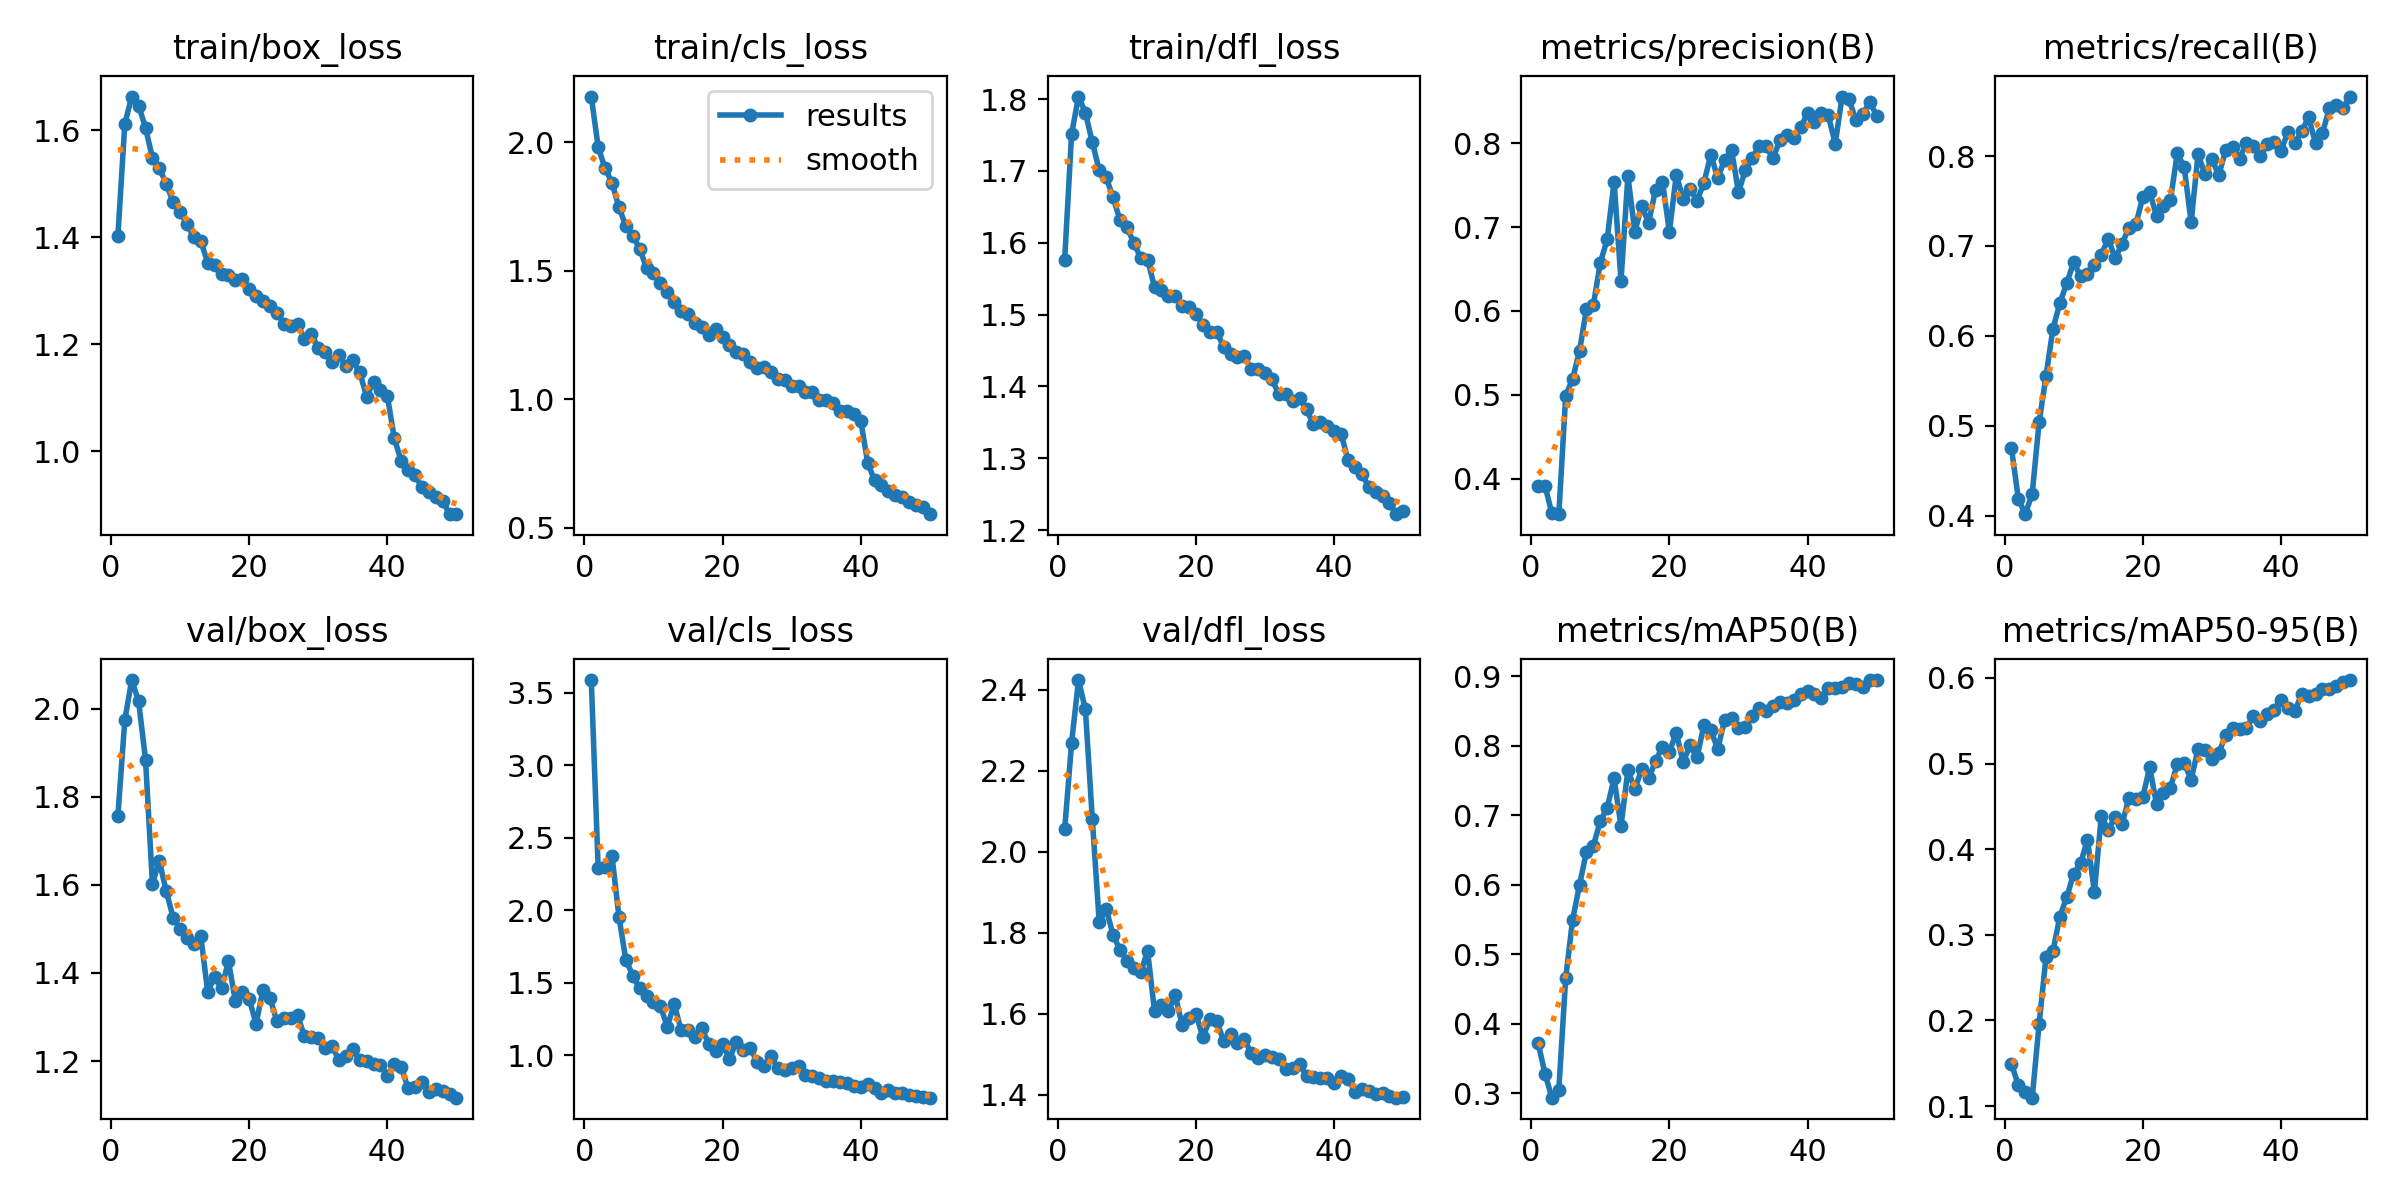

In [108]:
from IPython.display import Image, display

display(Image(
    filename="/content/fall_training/fall_detection/results.png"
))

In [111]:
import os

for root, dirs, files in os.walk("/content"):
    if "data.yaml" in files:
        print(os.path.join(root, "data.yaml"))

/content/fall_dataset/data.yaml


In [112]:
from ultralytics import YOLO

model = YOLO("/content/fall_training/fall_detection/weights/best.pt")

metrics = model.val(
    data="/content/fall_dataset/data.yaml",
    imgsz=640
)

print("\n===== PERFORMANCE =====")
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 689.2±297.7 MB/s, size: 27.3 KB)
val: Scanning /content/fall_dataset/valid/labels.cache... 899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 163.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 6.4it/s 8.9s
                   all        899        899      0.833      0.863      0.893      0.597
Speed: 1.0ms preprocess, 2.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val-3

===== PERFORMANCE =====
Precision : 0.8326015999603728
Recall    : 0.8630796859246441
mAP50     : 0.8931414400897204
mAP50-95  : 0.5970424535667764


In [113]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "confusion_matrix" in file:
            print(os.path.join(root, file))

/content/runs/detect/val-3/confusion_matrix_normalized.png
/content/runs/detect/val-3/confusion_matrix.png
/content/runs/detect/val-2/confusion_matrix_normalized.png
/content/runs/detect/val-2/confusion_matrix.png
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/confusion_matrix.png
/content/fall_training/fall_detection/confusion_matrix_normalized.png
/content/fall_training/fall_detection/confusion_matrix.png


In [116]:
from ultralytics import YOLO

model = YOLO("/content/fall_training/fall_detection/weights/best.pt")

results = model.predict(
    source="https://www.dreamstime.com/photos-images/old-person-falling.html",
    conf=0.5,
    save=True
)

print("✅ Prediction completed")

ConnectionError: 1/1: https://www.dreamstime.com/photos-images/old-person-falling.html... Failed to open https://www.dreamstime.com/photos-images/old-person-falling.html

In [117]:
from ultralytics import YOLO

model = YOLO("/content/fall_training/fall_detection/weights/best.pt")

metrics = model.val(
    data="/content/fall_dataset/data.yaml",
    imgsz=640
)

print("\n========== VALIDATION RESULTS ==========")
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 748.1±814.0 MB/s, size: 43.1 KB)
val: Scanning /content/fall_dataset/valid/labels.cache... 899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 198.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 6.0it/s 9.4s
                   all        899        899      0.833      0.863      0.893      0.597
Speed: 1.2ms preprocess, 2.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val-4

========== VALIDATION RESULTS ==========
Precision : 0.8326015999603728
Recall    : 0.8630796859246441
mAP50     : 0.8931414400897204
mAP50-95  : 0.5970424535667764


In [118]:
import os

path = "/content/fall_training/fall_detection/weights/best.pt"

size = os.path.getsize(path) / (1024 * 1024)

print("Model size:", round(size, 2), "MB")

Model size: 5.2 MB
